# **ΜΕΡΟΣ Α**

Εργασια Μιχαηλ Μπαλτζακη : 10989
        Αγγελου Γουργαρη : 11164

##Φόρτωση του αρχείου dataset1.csv και μετατροπή σε pandas dataframe

In [ ]:

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D

uploaded = files.upload()
my_cols = ['feature1', 'feature2', 'Label']
df = pd.read_csv('data/dataset1.csv', header=None, names=my_cols)

display(df.head())

Saving dataset1.csv to dataset1.csv
User uploaded file "dataset1.csv" with length 12253 bytes


,feature1,feature2,Label
0,24.974680,14.504545,0.0
1,27.090095,12.305978,0.0
2,19.153230,1.122443,0.0
3,32.980913,28.787312,0.0
4,31.816648,18.804721,0.0


##Υπολογισμός παραμέτρων κανονικών κατανομών

In [2]:
classes = np.unique(df['Label'])



# Χωρισμος ανα κλασεις
data_np = np.array([df[df['Label'] == c].drop('Label', axis=1)  for c in classes])

# Υπολογισμός μέσου όρου
means_arr = np.array([np.sum(data_np[i], axis=0)/len(data_np[i]) for i in range(len(classes)) ])
X_minus_M = np.array([data_np[i] - means_arr[i] for i in range(len(classes))])

# Υπολογισμος Σ
stds_arr = np.array([X_minus_M[i].T @ X_minus_M[i] / (len(data_np[i])) for i in range(len(classes))] )

for i in range(len(classes)):
  print(f"For Class {i}:\nμ = {means_arr[i]} \nΣ={stds_arr[i]}\n\n")





For Class 0:
μ = [29.20903802 16.84988855] 
Σ=[[46.98591258 22.90532295]
 [22.90532295 48.63133559]]


For Class 1:
μ = [40.19766916 34.28109099] 
Σ=[[ 9.42390491 11.48971771]
 [11.48971771 20.10805596]]


For Class 2:
μ = [27.55232503 34.79318037] 
Σ=[[13.96874391 11.77433636]
 [11.77433636 25.28848192]]




##Διάγραμμα

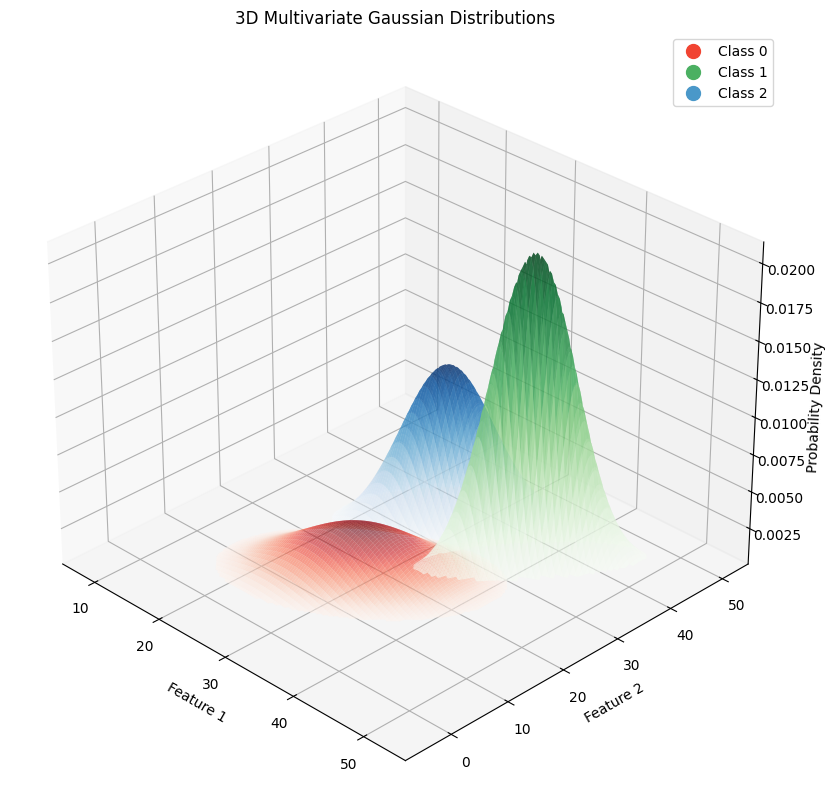

In [3]:

#θα τη χρησιμοποιήσω για να βγάλω το Legend
from matplotlib.lines import Line2D

def multivariate_normal_pdf(x, mean, determinant, inverse):
  return np.exp(-(x-mean).T @ inverse @(x-mean) /2) / np.sqrt(((2*np.pi)**2) * determinant)

# Ορια γραφηματος
f1_min, f1_max = df['feature1'].min() - 5, df['feature1'].max() + 5
f2_min, f2_max = df['feature2'].min() - 5, df['feature2'].max() + 5

# Σημεία για διάγραμμα
x1 = np.linspace(f1_min, f1_max, 150)
x2 = np.linspace(f2_min, f2_max, 150)
X, Y = np.meshgrid(x1, x2)
points = np.dstack((X, Y))
# reshpae για να το δωσουμε στη συναρτηση
points = points.reshape(-1, 2)

# Ορίζουσα και αντίστροφος του Σ
determinant = np.array([(stds_arr[i][0][0] * stds_arr[i][1][1])-(stds_arr[i][0][1] * stds_arr[i][1][0])   for i in range(len(classes))])
inverse = np.array([[[stds_arr[i][1][1],-stds_arr[i][0][1]], [-stds_arr[i][1][0], stds_arr[i][0][0]]] / determinant[i] for i in range(len(classes))])

# Υπολογισμός συνάρτησης στα σημεία μας
Z = np.zeros([len(classes), len(points)])
for i in range(len(classes)):
  Z[i] = ([multivariate_normal_pdf(point, means_arr[i], determinant[i], inverse[i]) for point in points])

# reshape το Ζ ωστε να φτιαξουμε το διαγραμμα
Z = Z.reshape(3, 150, 150)

# --- Σχεδίαση ---
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection='3d')
cmaps = ['Reds', 'Greens', 'Blues']
labels = ['Class 0', 'Class 1', 'Class 2']
proxy_lines = []

# Θέτουμε το πάτωμα του γραφήματος
z_floor = 0

for z, cmap, label in zip(Z, cmaps, labels):

    # ΕΞΑΦΑΝΙΣΗ ΑΣΠΡΟΥ ΧΑΛΙΟΥ
    # Φτιάχνουμε αντίγραφο για να μην χαλάσουμε τα δεδομένα του contour
    z_surf = z.copy()
    # Κόβουμε οτιδήποτε είναι κάτω από 0.0005
    z_surf[z_surf < 0.0005] = np.nan

    # PLOT (Τα βουνά)
    surf = ax.plot_surface(X, Y, z_surf, cmap=cmap, alpha=0.6,
                           linewidth=0, antialiased=True,
                           rstride=2, cstride=1) # Strides για ταχύτητα

    # Legend με trick
    fake_line = Line2D([0], [0], linestyle="none", c=plt.get_cmap(cmap)(0.6), marker='o', markersize=10)
    proxy_lines.append(fake_line)


ax.set_title('3D Multivariate Gaussian Distributions')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Probability Density')
ax.legend(proxy_lines, labels)
ax.view_init(elev=30, azim=-45)

plt.show()

# **ΜΕΡΟΣ** **Β**

##Φόρτωση του dataset2.csv και μετατροπή σε pandas dataframe

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

uploaded = files.upload()
my_cols = ['feature']
df = pd.read_csv('data/dataset2.csv', header=None, names=my_cols)

display(df.head())

Saving dataset2.csv to dataset2.csv
User uploaded file "dataset2.csv" with length 3889 bytes


,feature
0,0.444337
1,0.792534
2,2.545026
3,-2.240528
4,-3.414621


##Ιστόγραμμα δεδομένων

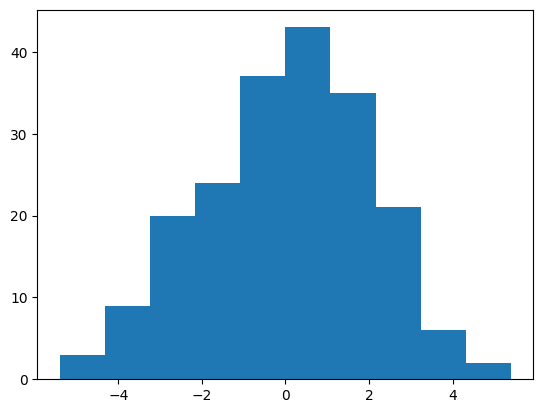

In [5]:
# Ιστόγραμμα
plt.hist(df['feature'])
plt.show()

##Εκτίμηση συνάρτησης πιθανοφάνειας και εύρεση βέλτιστου h για ελαχιστοποίηση του Mse

In [6]:
import sympy as sp
N = df.shape[0]
#GAUSSIAN KERNEL

#Έχω ακολουθήσει την symbolic προσέγγιση ώστε να τυπώσω και τον τελικό τύπο

#Συμβολικές μεταβλητές
x, h = sp.symbols('x h')
n, i = sp.symbols('N i', integer=True) # Ν = πλήθος, i = δείκτης αθροίσματος

# γράφουμε xi[i] που εμφανίζεται ως x_i
xi = sp.IndexedBase('x_i')

# Ορίζουμε τον όρο μέσα στο άθροισμα (τον Kernel)
# Χρησιμοποιούμε το xi[i] αντί για σκέτο xi
term = (1 / (sp.sqrt(2 * sp.pi) * h)) * sp.exp(-((x - xi[i])**2) / (2 * h**2))
summation = sp.Sum(term, (i, 1, N))

# διαιρούμε και με N και έχουμε τον τύπο χωρίς αντικατάσταση ακόμη
parzen_formula = (1/N) * summation
# Για να βγει ομορφος ο τυπος
sp.init_printing(pretty_print=True)
display(parzen_formula)

#Αντικατασταση ωστε να μεινει μονο το x και το h
array_to_sum = [term.subs({xi[i]: val}) for val in df['feature']]
final_density = sum(array_to_sum)/N

#Μετατροπή σε γρήγορη συνάρτηση
func = sp.lambdify((x, h), final_density, 'numpy')

#Σύγκριση της συνάρτησης που βρήκα με την Ν(1,4) για διάφορες τιμές του h
test_df = df.copy()
test_score = {}
i = 0.01
for i in np.arange(0.1, 10.0, 0.1):
  # Το i παίζει το ρόλο του h στο loop τεσταρω για h απο 0.1 εως 10
  test_df['Parzen_values']   = func(test_df['feature'], i)
  test_df['gaussian_values'] = norm.pdf(test_df['feature'], loc=1, scale=2)
  test_df['square_diff']            = (test_df['Parzen_values'] - test_df['gaussian_values'])**2
  test_score[i] = test_df['square_diff'].mean()

# παιρνω απο το dictionary το καλυτερο h και το σφαλμα που το αντιπροσωπευει
min_key = min(test_score, key=test_score.get)
lowest_mse = test_score[min_key]
best_h     = min_key

#HYPERCUBE KERNEL

# Αυτή τη φορά θα το υπολοιήσω με συνάρτηση
def parzen_hypercube_density(h, data_points, x, N):
    #επιστρεφει 1 αν ειμαστε μεσα 0 αν ειμαστε εξω. Ουσιαστικα επιστρεφει πινακα με True or False και γινονται 0 και 1 οταν κανουμε το sum
    points_inside_window = np.abs(data_points - x) <= (h / 2.0)
    k = np.sum(points_inside_window)
    return k / (N * h)

df_hypercube = df.copy()
test_score_cube = {}
i = 0.01
for i in np.arange(0.1, 10.0, 0.1):
  # Το i παίζει το ρόλο του h στο loop τεσταρω για h απο 0.1 εως 10
  par_cube_vals = np.array([parzen_hypercube_density(i, df_hypercube['feature'], x, N) for x in df_hypercube['feature']])
  df_hypercube['Parzen_values']   =  par_cube_vals
  df_hypercube['gaussian_values'] = norm.pdf(df_hypercube['feature'], loc=1, scale=2)
  df_hypercube['square_diff']     = (df_hypercube['Parzen_values'] - df_hypercube['gaussian_values'])**2
  test_score_cube[i] = df_hypercube['square_diff'].mean()

# παιρνω απο το dictionary το καλυτερο h και το σφαλμα που το αντιπροσωπευει
cube_min_key = min(test_score_cube, key=test_score_cube.get)
cube_lowest_mse = test_score_cube[cube_min_key]
cube_best_h     = cube_min_key


print(f"lowest_mse = {lowest_mse:.4f} while best_h = {best_h:.2f} for gaussian kernel")
print(f"lowest_mse = {cube_lowest_mse:.4f} while best_h = {cube_best_h:.2f} for hypercube kernel\n")



       200                      
      ______                    
      ╲                         
       ╲                      2 
        ╲        -(x - x_i[i])  
         ╲       ───────────────
          ╲              2      
0.005⋅    ╱           2⋅h       
         ╱   √2⋅ℯ               
        ╱    ───────────────────
       ╱           2⋅√π⋅h       
      ╱                         
      ‾‾‾‾‾‾                    
      i = 1                     

lowest_mse = 0.0011 while best_h = 0.80 for gaussian kernel
lowest_mse = 0.0011 while best_h = 2.80 for hypercube kernel



##Διαγράμματα mse-h

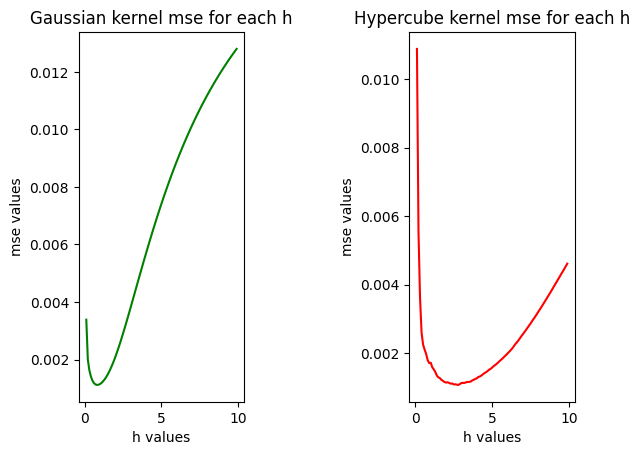

In [7]:
#PLOTS
plt.subplot(1, 2, 1)
plt.plot(test_score.keys(), test_score.values(), 'green')
plt.xlabel('h values')
plt.ylabel('mse values')
plt.title('Gaussian kernel mse for each h')

plt.subplot(1, 2, 2)
plt.plot(test_score_cube.keys(), test_score_cube.values(), 'red')
plt.xlabel('h values')
plt.ylabel('mse values')
plt.title('Hypercube kernel mse for each h')

plt.subplots_adjust(wspace=1)
plt.show()

#**ΜΕΡΟΣ Γ**




##Φόρτωση των αρχεiων dataset3.csv και testset.csv και μετατροπή σε pandas dataframe

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from matplotlib.colors import ListedColormap
# Ανοίγουμε και τα δύο αρχεία ταυτόχρονα με Ctrl+click

uploaded = files.upload()
my_cols = ['feature1', 'feature2', 'Label']

training_df = pd.read_csv('data/dataset3.csv', header=None, names=my_cols)
test_df =  pd.read_csv('data/testset.csv', header=None, names=my_cols)

display(training_df.head())
display(test_df.head())




Saving dataset3.csv to dataset3.csv
Saving testset.csv to testset.csv
User uploaded file "dataset3.csv" with length 2050 bytes
User uploaded file "testset.csv" with length 2046 bytes


,feature1,feature2,Label
0,12.007316,35.453344,0.0
1,15.858027,32.731539,0.0
2,14.544736,34.727899,0.0
3,14.336451,27.530280,0.0
4,17.153298,28.657292,0.0


,feature1,feature2,Label
0,5.592195,35.699919,1.0
1,13.333622,40.289180,0.0
2,10.733250,28.256243,1.0
3,6.252529,25.736509,1.0
4,12.308845,29.037706,1.0


##Βοηθητικές Συναρτήσεις

In [9]:
def eucl(x, trainData):

    # Βρίσκω τη διαφορά αφαιρωντας το x απο καθε γραμμη του πινακα μου
    diff = trainData - x

    # Υψωνω στο τεραγωνο ολα τα στοιχεια του πινακα
    sq_diff = diff ** 2

    # Αθροιζω ανα γραμμη και εχω φτιαξει το (x_i1-x1)² +(x_i2-x2)² σε καθε γραμμη , x= (x1,x2)
    sum_sq = np.sum(sq_diff, axis=1)

    # Ριζωνω
    return np.sqrt(sum_sq)

In [10]:
def neighbors(x, trainData, k, extra):
  distances = eucl(x, trainData)

  # Είναι σε ascending order τα index
  sorted_distances_index = np.argsort(distances)
  # Το κανω descending
  sorted_distances_index = sorted_distances_index[::-1]
  # Αποστασεις με φθινουσα σειρα
  sorted_distances = distances[sorted_distances_index]

  # Αν ειμαστε στο KNN estimation επιστρεφω αποστασεις ειναι πινακας Κ x 2
  if extra == 1:
    return trainData[sorted_distances_index[-k:]]
  # Αν ειμαστε στον κλασικο ΚΝΝ επιστρεφω τα indices των γειτονων ειναι διανυσμα Κ
  if extra == 0:
    return sorted_distances_index[-k:]


In [11]:
def predict_extra(testData, trainData, k):
  extra = 1
  N = len(trainData)
  V0 = V1 = None
  # Κανουμε split σε 2 dataset ενα για καθε κλαση
  trainData_class = [trainData[trainData['Label' ]== i] for i in range(2)]
  N0 = len(trainData_class[0])
  N1 = len(trainData_class[1])
  # Στην πρωτη επαναληψη ψαχνω μονο για γειτονες με Label=0 ενω στη δευτερη μονο για Label=1
  for i, tr_df in enumerate(trainData_class):
    # Μετατροπη pandas σε numpy για τα features
    train_data_np = tr_df.drop(columns=['Label']).to_numpy()
    test_data_np = testData
    #test_data_np = testData[['feature1', 'feature2']].to_numpy()
    #Βρισκω τους Κ γειτονες καθε σημειου του testData, ο πινακας ειναι τρισδιαστατος ωστε να εχω ενα πινακα για καθε test sample
    neighbors_matrix = np.array([neighbors(test_sample, train_data_np, k, extra) for test_sample in test_data_np])
    # Καθε γραμμη περιεχει το διανυσμα του μακρυνοτερου γειτονα για καθε test sample
    furthest_neighbor_coordinates = neighbors_matrix[:, 0, :]
    # Αποσταση του καθε test sample απο τον μακρυνοτερο γειτονα του
    furthest_distances = eucl(furthest_neighbor_coordinates, test_data_np)
    # Το V0 περιεχει τον μακρυνοτερο γειτονα κλασσης 0 για καθε test sample που αντιπροσωπευει την ακτινα της σφαιρας
    # Το V1 περιεχει τον μακρυνοτερο γειτονα κλασσης 1 για καθε test sample που αντιπροσωπευει την ακτινα της σφαιρας
    if i == 0:
      V0 = np.pi*furthest_distances**2
    else:
      V1 = np.pi*furthest_distances**2

  p0 = k/(V0*N0)
  p1 = k/(V1*N1)

  final_p0 = (p0*(N0/N))/(p0*(N0/N)+p1*(N1/N))
  final_p1 = (p1*(N1/N))/(p0*(N0/N)+p1*(N1/N))
  return [final_p0, final_p1]

In [12]:
def predict(testData, trainData, k):
  extra = 0
  N = len(trainData)
  # Μετατροπη pandas σε numpy για τα features
  train_data_np = trainData.drop(columns=['Label']).to_numpy()
  test_data_np = testData
  #Βρισκω τους Κ γειτονες καθε σημειου του testData(τα indices), εχω ενα διανυσμα για καθε test sample
  neighbors_matrix = np.array([neighbors(test_sample, train_data_np, k, extra) for test_sample in test_data_np])
  # Κανω το labels numpy
  Labels_np = trainData['Label'].to_numpy()
  # Το Labels_np[neighbors_matrix] θα μας δωσει ενα Ν x Κ πινακα που καθε γραμμη του εχει τις τιμες του Label των γειτονων για καθε test sample αθροιζουμε για να βρουμε το Κ1
  k1 = np.sum(Labels_np[neighbors_matrix], axis=1)
  k0 = k - k1
  # Το κανουμε πιθανοτητα
  p1 = k1/k
  p0 = k0/k

  ties = (p1 == 0.5)
  tie_indices = np.flatnonzero(ties)
  # Αν εχω ισοπαλλιες
  if len(tie_indices)>0:
    # Πινακας με την αποσταση καθε γειτονα του test sample απο το test sample, για καθε test sample που ηρθε ισοπαλια
    tie_distances = np.array([eucl(test_data_np[tie_index], train_data_np[neighbors_matrix[tie_index]]) for tie_index in tie_indices])
    #Πινακας με το Label καθε γειτονα του test sample, για καθε test sample που ηρθε ισοπαλια
    tie_neighbors_labels = np.array([Labels_np[neighbors_matrix[tie_index]] for tie_index in tie_indices])
    # Βρισκω ποιες αποστασεις ανηκουν στην καθε μια κλαση

    class0_indices = np.array([np.flatnonzero(tie_neighbors_labels[i] == 0) for i in range(tie_indices.shape[0])])
    class1_indices = np.array([np.flatnonzero(tie_neighbors_labels[i] == 1) for i in range(tie_indices.shape[0])])

    class0_distances = np.array([distance[index]  for index, distance in zip(class0_indices, tie_distances)])
    class1_distances = np.array([distance[index]  for index, distance in zip(class1_indices, tie_distances)])
    # Διαλεγω την κλαση που εχει το μικροτερο final_distance
    final_class0_distance = np.sum(class0_distances, axis=1)
    final_class1_distance = np.sum(class1_distances, axis=1)
    # Βρισκω ποια indices του πινακα tie_indices πρεπει να γινουν ποια κλαση
    tie_classifier0 = np.flatnonzero(final_class0_distance < final_class1_distance)
    tie_classifier1 = np.flatnonzero(final_class0_distance > final_class1_distance)
    #Αυξανα πολυ λιγο την p0 ωστε να ταξινομησω στο 0 και μειωνω κατα το ιδιο ποσο την p1
    p0[tie_indices[tie_classifier0]] = p0[tie_indices[tie_classifier0]] +0.001
    p1[tie_indices[tie_classifier0]] = p1[tie_indices[tie_classifier0]] -0.001
    # Το αντιθετο για να ταξινιμησω στο 1
    p0[tie_indices[tie_classifier1]] = p0[tie_indices[tie_classifier1]] -0.001
    p1[tie_indices[tie_classifier1]] = p1[tie_indices[tie_classifier1]] +0.001

  return [p0, p1]



##Εύρεση βέλτιστιου k για μεγιστοποιήση ακρίβειας και διαγράμματα h-ακρίβειας

max_accuracy = 0.74 for k = 11

max_accuracy_extra = 0.74 for k = 6



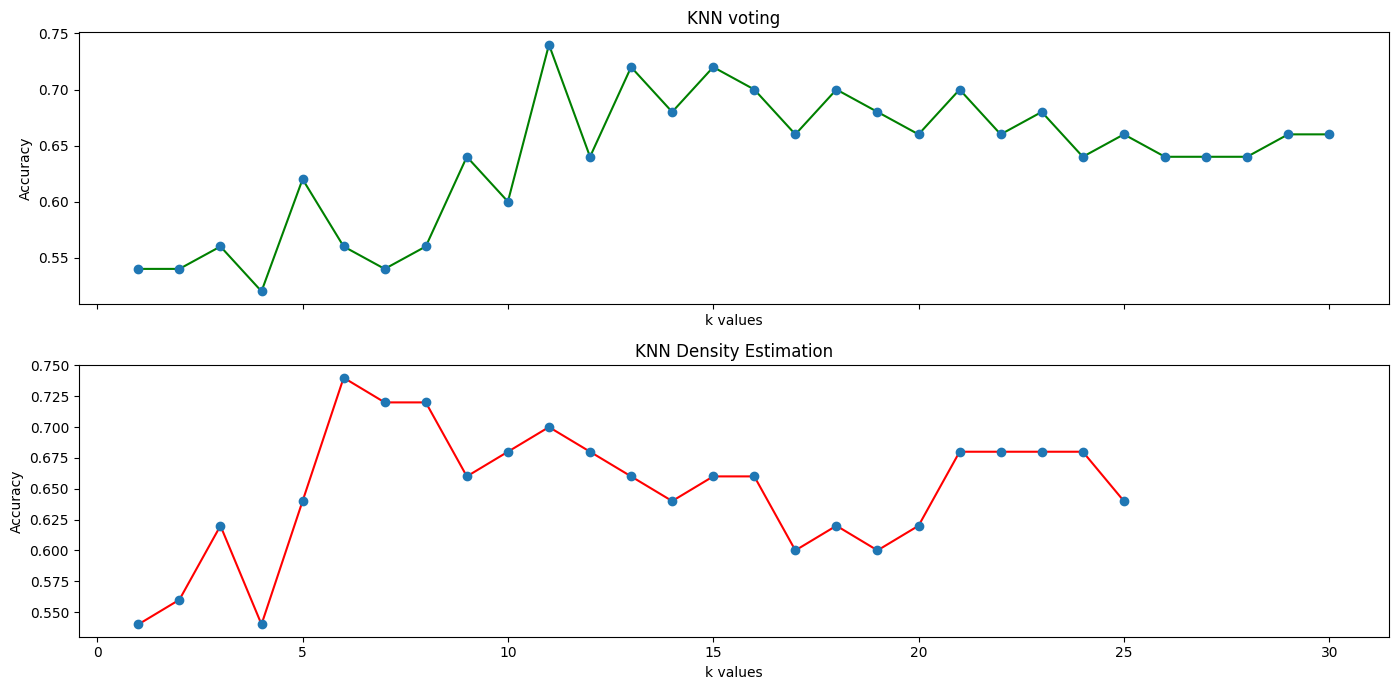

In [13]:

test_data_np = test_df[['feature1', 'feature2']].to_numpy()

final_p_extra = np.array([predict_extra(test_data_np, training_df, k)  for k in range(1,26)])
final_p = np.array([predict(test_data_np, training_df, k) for k in range(1,31)])

Labels_np = test_df['Label'].to_numpy()

#Αν ο classification εχει τιμη true ταξινομω στην 1 αν εχει false ταξινομω στην 0. το 50-50 το εχω διευθετηση στην predict
classification = (final_p[:, 1, :] - final_p[:, 0, :])>=0
classification_extra = (final_p_extra[:, 1, :] - final_p_extra[:, 0, :])>=0
# Πινακας που οπου εχει 0 εχουμε ταξινομησει σωστα ενω οπου εχει +1 ή -1 εχουμε ταξινομησει λαθος
correctly_classified = classification - Labels_np
correctly_classified_extra = classification_extra - Labels_np
#μετραω ποσα μηδενικα εχει ο πινακας σε καθε γραμμη και τοσα ειναι τα σωστα ταξινομημενα στοιχεια για το εκαστοτε Κ.
# correctly_classified==0 επιστρεφει ενα πινακα που εχει true οπου εχω 0 και false οπου εχω 1 και μετα για να μετρησω τα μηδενικα ανα γραμμη μετραω τα nonzero(true) του πινακα
correct_number = np.count_nonzero((correctly_classified == 0), axis=1)
correct_number_extra = np.count_nonzero((correctly_classified_extra == 0), axis=1)

accuracy = correct_number/len(test_df)
accuracy_extra = correct_number_extra/len(test_df)

max_accuracy_index = np.argmax(accuracy)
max_accuracy_index_extra = np.argmax(accuracy_extra)

max_accuracy = accuracy[max_accuracy_index]
max_accuracy_extra = accuracy_extra[max_accuracy_index_extra]

best_k = max_accuracy_index + 1
best_k_extra = max_accuracy_index_extra + 1

print(f"max_accuracy = {max_accuracy} for k = {best_k}\n")
print(f"max_accuracy_extra = {max_accuracy_extra} for k = {best_k_extra}\n")

# Διαγραμματα
k_vals = np.arange(1, 31, 1)
k_vals_extra = np.arange(1, 26, 1)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 7))

ax1.plot(k_vals, accuracy, 'green')
ax1.plot(k_vals, accuracy, 'o')
ax1.set_xlabel('k values')
ax1.set_ylabel('Accuracy')
ax1.set_title('KNN voting')

ax2.plot(k_vals_extra, accuracy_extra, 'red')
ax2.plot(k_vals_extra, accuracy_extra, 'o')
ax2.set_xlabel('k values')
ax2.set_ylabel('Accuracy')
ax2.set_title('KNN Density Estimation')

plt.tight_layout()
plt.show()



##Περιοχές απόφασης

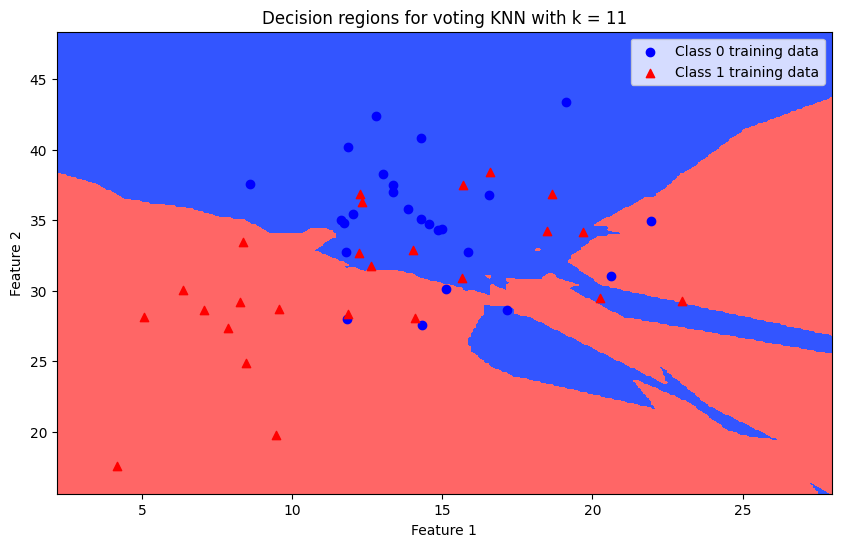

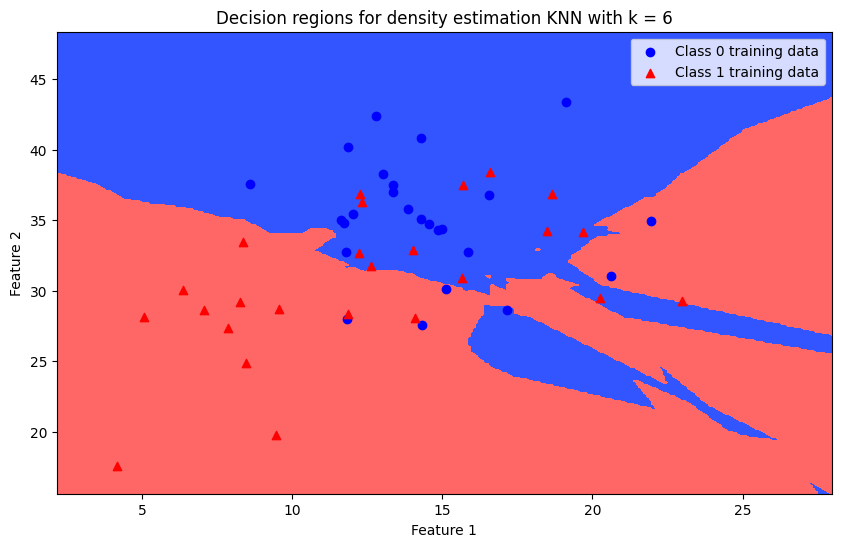

In [14]:
# Περιοχες αποφασης
train_dat = training_df.drop(columns=['Label']).to_numpy()
training_class0_np = training_df[training_df['Label'] == 0].drop(columns=['Label']).to_numpy()
training_class1_np = training_df[training_df['Label'] == 1].drop(columns=['Label']).to_numpy()

test_data_np = test_df.drop(columns=['Label']).to_numpy()
test_class0_np = test_df[test_df['Label'] == 0].drop(columns=['Label']).to_numpy()
test_class1_np = test_df[test_df['Label'] == 1].drop(columns=['Label']).to_numpy()

# διαλεγω linspace με 300 σημεια για καθε αξονα ωστε να παρω υψηλη αναλυση στο σχημα μου
x1 = np.linspace(train_dat[:, 0].min()-2, train_dat[:, 0].max()+5, 300)
x2 = np.linspace(train_dat[:, 1].min()-2, train_dat[:, 1].max()+5, 300)
X1, X2 = np.meshgrid(x1, x2)
# Τεχνικη ωστε να κανω reshape ωστε να εχω το grid σε μορφη 90000 x2
# το ravel κανει flatten και με το np.c_ βαζω τα δυο flat διανυσματα διπλα διπλα ωστε να παρω τη μορφη που θελω
grid_points = np.c_[X1.ravel(), X2.ravel()]

predictions = np.array(predict(grid_points, training_df, best_k))
predictions_extra = np.array(predict_extra(grid_points, training_df, best_k_extra))

predictions_classification = (predictions[1, :] - predictions[0, :])>=0
predictions_classification_extra = (predictions_extra[1, :] - predictions_extra[0, :])>=0
# Επαναφορα σε 300 x 300 για την contourf
grid_results = predictions_classification.reshape(X1.shape)
grid_results_extra = predictions_classification_extra.reshape(X1.shape)

# Φτιαχνω ενα custom_cmap ωστε να εχω αποχρωσεις των σημειων για την καθε περιοχη
custom_cmap = ListedColormap(['#3355FF', '#FF6666'])
# voting διαγραμμα
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, grid_results, cmap=custom_cmap )
#---------για να κανω Plot τα training samples
plt.scatter(training_class0_np[:, 0], training_class0_np[:, 1], color='blue', marker='o', label='Class 0 training data')
plt.scatter(training_class1_np[:, 0], training_class1_np[:, 1], color='red', marker='^', label='Class 1 training data')
#--------για να κανω Plot τα test samples
#plt.scatter(test_class0_np[:, 0], test_class0_np[:, 1], color='blue', marker='o', label='Class 0 test data')
#plt.scatter(test_class1_np[:, 0], test_class1_np[:, 1], color='red', marker='^', label='Class 1 test data')
#--------------
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title(f"Decision regions for voting KNN with k = {best_k}")
plt.show()
# density estimation διαγραμμα
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, grid_results_extra, cmap=custom_cmap )
#---------για να κανω Plot τα training samples
plt.scatter(training_class0_np[:, 0], training_class0_np[:, 1], color='blue', marker='o', label='Class 0 training data')
plt.scatter(training_class1_np[:, 0], training_class1_np[:, 1], color='red', marker='^', label='Class 1 training data')
#--------για να κανω Plot τα test samples
#plt.scatter(test_class0_np[:, 0], test_class0_np[:, 1], color='blue', marker='o', label='Class 0 test data')
#plt.scatter(test_class1_np[:, 0], test_class1_np[:, 1], color='red', marker='^', label='Class 1 test data')
#--------------

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title(f"Decision regions for density estimation KNN with k = {best_k_extra}")
plt.show()
#θα δουμε οτι τα διαγραμματα για το καλυτερο Κ για καθε υλοποιηση βγαινουν ακριβως ιδια.
